# Human Activity Recognition on PAMAP2 — Project Walkthrough

This notebook walks through the **actual project code** (`har/`, `experiments/`) and the **actual saved results** (`results/`, `artifacts/`).

**How to read it**

* Every number in a results table is loaded from a file written by the experiments (`results/metrics/*.json`, `results/metrics/*_cv.csv`, `results/confusion/*.csv`). Nothing is typed in by hand.
* Model code is shown with `inspect.getsource(...)` on the real project modules, so what you see is what was run.
* **No model is retrained here.** Cells that would retrain a model are guarded by `RUN_EXPENSIVE = False` and are skipped.
* Every result carries a **status**, assigned by the project's own `experiments.compare_results.classify`:

| Status | Meaning |
|---|---|
| **FULL** | trained on all 1,633,207 training rows and tested on all 288,213 test rows of the frozen split |
| **SUBSAMPLE** | trained and/or tested on fewer rows than the frozen split (compute limits) |
| **QUICK** | a fixed, reduced-compute educational preset (no tuning, short training): **not** comparable to FULL results |

**Requirements:** run from inside the repository (any sub-folder) with the project's Python environment. Sections 3, 4, 6, 16 and 17 also need the processed dataset in `data/processed/` and, for section 4, the raw data in `data/raw/`; without them those cells print a message instead of failing.

## 1. Project Overview

**Human Activity Recognition (HAR)** means working out what a person is doing (lying, walking, cycling, …) from body-worn sensor readings. This project treats it as **supervised multi-class classification**: each 100 Hz sensor reading is one sample and the activity label is the target.

**Dataset: PAMAP2 Physical Activity Monitoring** (UCI). Nine subjects wore three inertial measurement units (IMUs) on the **hand, chest and ankle**, plus a heart-rate monitor. Each IMU records temperature, two 3-axis accelerometers (±16 g, ±6 g), a 3-axis gyroscope, a 3-axis magnetometer and an orientation estimate. We use the *Protocol* recordings.

**Objective:** reproduce and compare the classifiers studied in the reference report (Athens et al., 2018): logistic regression, SVM, decision tree, random forest, AdaBoost and an MLP. Each is evaluated on two feature sets, under one fixed experimental protocol:

* **12 protocol activities** (table below). The transient label `0` is removed.
* **One frozen random split**: 85 % train / 15 % test at the row level, `seed = 229`. It is created once, saved to disk and identified by a fingerprint, so every model sees exactly the same rows.
* **Reduced vs full features**: *reduced* = hand IMU + heart rate (**11** features), the cheaper single-sensor setup. *Full* = all three IMUs + heart rate (**31** features).
* Hyperparameters are tuned with **5-fold cross-validation on training rows only**. The test split is used once, for the final evaluation.

In [1]:
import os, sys, json, inspect
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # keep TensorFlow import quiet (section 12)

# Locate the repository root (works when opened from notebooks/ or from the root itself).
REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "har" / "config.py").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook inside the project repository (har/config.py not found).")
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("Repository root:", REPO_ROOT.name)

Repository root: human-activity-recognition-ML


In [2]:
import pandas as pd
from har.config import ACTIVITY_NAMES, LABEL_ORDER

cleaning_log = json.loads(Path("results/cleaning_log.json").read_text())
counts = {int(k): v for k, v in cleaning_log["class_counts"].items()}
activities = pd.DataFrame({"Activity ID": LABEL_ORDER,
                           "Activity": [ACTIVITY_NAMES[c] for c in LABEL_ORDER],
                           "Rows after cleaning": [counts[c] for c in LABEL_ORDER]})
activities["Share"] = activities["Rows after cleaning"] / activities["Rows after cleaning"].sum()
print(f"{len(activities)} activities, {activities['Rows after cleaning'].sum():,} rows in total")
activities.style.format({"Rows after cleaning": "{:,}", "Share": "{:.1%}"}).hide(axis="index")

12 activities, 1,921,420 rows in total


Activity ID,Activity,Rows after cleaning,Share
1,lying,"192,290",10.0%
2,sitting,"184,645",9.6%
3,standing,"188,984",9.8%
4,walking,"229,709",12.0%
5,running,"95,630",5.0%
6,cycling,"163,302",8.5%
7,Nordic walking,"184,444",9.6%
12,ascending stairs,"117,094",6.1%
13,descending stairs,"104,865",5.5%
16,vacuum cleaning,"174,976",9.1%


## 2. Imports

Third-party libraries (NumPy, pandas, scikit-learn, Matplotlib, joblib; TensorFlow/Keras only for the MLP), then the **project's own modules**:

| Module | Role |
|---|---|
| `har.config` | frozen constants: seed, test fraction, activity names, feature sets |
| `har.data` | loading + cleaning PAMAP2, `get_xy` (features/labels for a feature set) |
| `har.splits` | the frozen random split and its fingerprint |
| `har.runner` | the shared *fit → predict → time → save* routine used by every experiment |
| `har.metrics` | accuracy / macro-F1 / weighted-F1 and the result-file format |
| `har.models_p1`, `har.models_p2` | one module per classifier |
| `experiments.compare_results` | the project's status rules (FULL / SUBSAMPLE / QUICK / NOT RUN) |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn

from har import config
from har.config import (SEED, TEST_FRACTION, N_FOLDS, FEATURE_SETS, FORBIDDEN_FEATURES,
                        TRANSIENT_LABEL, RESULTS_DIR, PROCESSED_DIR, RAW_DIR, RAW_COLUMNS)
from har import data as har_data
from har.data import get_xy, PROCESSED_FILE, KEEP_RAW
from har.splits import load_split, split_fingerprint, make_random_split
from har.runner import run_experiment
from har.metrics import evaluate, confusion_df
from har.models_p1 import logreg, svm
from har.models_p2 import decision_tree, random_forest, adaboost, mlp
from experiments import compare_results as cr

RUN_EXPENSIVE = False   # True would RETRAIN models (minutes to hours). Leave False for review.

PARQUET = PROCESSED_DIR / PROCESSED_FILE
HAVE_PROCESSED = PARQUET.is_file() and (PROCESSED_DIR / "split_random_seed229.npz").is_file()
SPLIT_COUNTS = cr.load_split_counts(RESULTS_DIR)
print(f"scikit-learn {sklearn.__version__}, numpy {np.__version__}, pandas {pd.__version__}")
print("processed data available:", HAVE_PROCESSED)


# ---- helpers used by every results section (they only READ saved files) ----
MODEL_NAMES = cr.MODELS            # stem -> display name, e.g. "decision_tree" -> "Decision Tree"

def load_result(stem):
    # One saved result record: results/metrics/<stem>.json
    return json.loads((RESULTS_DIR / "metrics" / f"{stem}.json").read_text())

def status_of(stem, rec):
    # FULL / SUBSAMPLE / QUICK, decided by the project's own compare_results.classify
    _, _, tag = cr._split_stem(stem)
    return cr.classify(rec, tag or "", SPLIT_COUNTS)

def results_table(stems):
    rows = []
    for stem in stems:
        r = load_result(stem)
        rows.append({"Model": MODEL_NAMES[r["model"]], "Feature Set": r["feature_set"].title(),
                     "Status": status_of(stem, r), "Accuracy": r["test_accuracy"],
                     "Macro F1": r["test_macro_f1"], "Weighted F1": r["test_weighted_f1"],
                     "Fit Time (s)": r["fit_seconds"], "Train rows": r["n_train"], "Test rows": r["n_test"]})
    return pd.DataFrame(rows)

def show(df):
    fmt = {c: "{:.2%}" for c in ("Accuracy", "Macro F1", "Weighted F1") if c in df}
    fmt.update({c: "{:,.1f}" for c in ("Fit Time (s)",) if c in df})
    fmt.update({c: "{:,}" for c in ("Train rows", "Test rows") if c in df})
    return df.style.format(fmt).hide(axis="index")

def source(obj):
    print(inspect.getsource(obj))

scikit-learn 1.9.1, numpy 2.4.6, pandas 3.0.6
processed data available: True


## 3. Dataset

The raw PAMAP2 files (~1.3 GB of space-separated text, 54 columns) are parsed **once** by `scripts/build_dataset.py`. That script writes a cleaned, compact **Parquet** file (`data/processed/pamap2_protocol_clean.parquet`) holding only the columns the project uses, stored as float32. Experiments load this file via `har.data.load_processed()`.

To keep this notebook light, we **do not load all 1.9 M rows** here. We read the file's metadata for its shape and only the first few rows for a preview.

In [4]:
import pyarrow.parquet as pq

if HAVE_PROCESSED:
    pf = pq.ParquetFile(PARQUET)
    print(f"Processed file : {PARQUET.relative_to(REPO_ROOT)}  ({PARQUET.stat().st_size / 1e6:.0f} MB)")
    print(f"Shape          : {pf.metadata.num_rows:,} rows x {pf.metadata.num_columns} columns")
    print("Columns        :", ", ".join(pf.schema_arrow.names[:8]), ", ...")
    preview_cols = ["row_id", "subject_id", "timestamp", "activity_id", "heart_rate",
                    "hand_temp", "hand_acc16_x", "chest_acc16_x", "ankle_acc16_x"]
    preview = pf.read_row_group(0, columns=preview_cols).slice(0, 5).to_pandas()
    display(preview.round(3))
else:
    print("Processed data not found - run `python -m scripts.build_dataset` first.")

Processed file : data\processed\pamap2_protocol_clean.parquet  (244 MB)
Shape          : 1,921,420 rows x 35 columns
Columns        : row_id, subject_id, timestamp, activity_id, heart_rate, hand_temp, hand_acc16_x, hand_acc16_y , ...


,row_id,subject_id,timestamp,activity_id,heart_rate,hand_temp,hand_acc16_x,chest_acc16_x,ankle_acc16_x
0,0,101,37.66,1,100.0,30.375,2.215,0.124,9.739
1,1,101,37.67,1,100.0,30.375,2.292,0.201,9.698
2,2,101,37.68,1,100.0,30.375,2.291,0.270,9.696
3,3,101,37.69,1,100.0,30.375,2.218,0.237,9.664
4,4,101,37.70,1,100.0,30.375,2.301,0.352,9.776


## 4. Data Cleaning

The cleaning policy lives in `har.data.clean_subject` and is applied **per subject** (so heart rate is never interpolated across two different people):

1. **Heart-rate interpolation.** The heart-rate monitor samples at ~9 Hz while the IMUs run at 100 Hz, so ~91 % of heart-rate cells are empty. They are filled by **linear interpolation in time** between the nearest real readings, inside each subject's recording only (`limit_area="inside"`, so no extrapolation).
2. **Remove the transient label `0`** ("other / transient activities": the gaps between protocol activities). Only the **12 protocol activities** are kept.
3. **Drop rows with NaN** in any of the 31 full-set features. The same rows are kept for both feature sets, so reduced and full models see identical samples.

The actual function:

In [5]:
source(har_data.clean_subject)

def clean_subject(df: pd.DataFrame, subject_id: int, hr_method: str = "linear"):
    """Apply the cleaning policy to one subject. Returns (clean_df, log_dict)."""
    log = {"subject_id": subject_id, "rows_raw": int(len(df)),
           "hr_nan_frac_raw": float(df["heart_rate"].isna().mean()),
           "rows_label0": int((df["activity_id"] == TRANSIENT_LABEL).sum())}
    if hr_method == "ffill":   # authors' code order: drop label 0 first
        df = df[df["activity_id"] != TRANSIENT_LABEL]
        df = fill_heart_rate(df, "ffill")
    else:                      # interpolate on the full time series first
        df = fill_heart_rate(df, hr_method)
    df = df[df["activity_id"].isin(LABEL_ORDER)]
    log["rows_after_label_filter"] = int(len(df))
    feats = FEATURE_SETS["full"]                 # same rows for BOTH feature sets
    nan_rows = df[feats].isna().any(axis=1)
    log["rows_dropped_nan"] = int(nan_rows.sum())
    df = df[~nan_rows].copy()
    df.insert(0, "subject_id", np.

**Live demonstration on a small slice of real raw data.** The first 60,000 lines of `subject101.dat` are parsed with the same column spec as `har.data.load_subject` and passed through the real `clean_subject`. This is a 10-minute excerpt, used only to show what each step does; the full-dataset totals follow below.

In [6]:
raw_file = RAW_DIR / "subject101.dat"
if raw_file.is_file():
    raw = pd.read_csv(raw_file, sep=r"\s+", header=None, names=RAW_COLUMNS, usecols=KEEP_RAW,
                      dtype="float64", nrows=60_000)          # same parsing as load_subject, first 60k lines
    raw["activity_id"] = raw["activity_id"].astype("int16")
    clean, log = har_data.clean_subject(raw, subject_id=101, hr_method="linear")
    print(f"raw rows                    : {log['rows_raw']:,}")
    print(f"heart-rate missing (raw)    : {log['hr_nan_frac_raw']:.1%}")
    print(f"rows with transient label 0 : {log['rows_label0']:,}  -> removed")
    print(f"rows after label filter     : {log['rows_after_label_filter']:,}")
    print(f"rows dropped for NaN        : {log['rows_dropped_nan']:,}")
    print(f"clean rows                  : {log['rows_clean']:,}")
    print(f"heart-rate missing (clean)  : {clean['heart_rate'].isna().mean():.1%}")
    print("labels before:", sorted(raw["activity_id"].unique().tolist()),
          "-> after:", sorted(clean["activity_id"].unique().tolist()))
else:
    print("Raw PAMAP2 files not found in data/raw - skipping the live demonstration.")

raw rows                    : 60,000
heart-rate missing (raw)    : 90.9%
rows with transient label 0 : 2,928  -> removed
rows after label filter     : 57,072
rows dropped for NaN        : 64
clean rows                  : 57,008
heart-rate missing (clean)  : 0.0%
labels before: [0, 1, 2, 3] -> after: [1, 2, 3]


**Full-dataset cleaning totals**, as logged by `scripts/build_dataset.py` in `results/cleaning_log.json`:

In [7]:
subj = pd.DataFrame(cleaning_log["subjects"])
subj_view = subj[["subject_id", "rows_raw", "hr_nan_frac_raw", "rows_label0", "rows_dropped_nan", "rows_clean"]]
total = subj_view[["rows_raw", "rows_label0", "rows_dropped_nan"]].sum().astype(int)
print(f"Raw rows             : {total['rows_raw']:,}")
print(f"Transient (label 0)  : {total['rows_label0']:,} removed")
print(f"Dropped for NaN      : {total['rows_dropped_nan']:,}")
print(f"Final usable rows    : {cleaning_log['rows_total']:,}  across {len(subj)} subjects, "
      f"{len(cleaning_log['class_counts'])} classes  (heart-rate method: {cleaning_log['hr_method']})")
subj_view.rename(columns={"subject_id": "Subject", "rows_raw": "Raw rows", "hr_nan_frac_raw": "HR missing",
                          "rows_label0": "Label-0 rows", "rows_dropped_nan": "NaN rows dropped",
                          "rows_clean": "Clean rows"}) \
    .style.format({"HR missing": "{:.1%}", "Raw rows": "{:,}", "Label-0 rows": "{:,}",
                   "NaN rows dropped": "{:,}", "Clean rows": "{:,}"}).hide(axis="index")

Raw rows             : 2,872,533
Transient (label 0)  : 929,661 removed
Dropped for NaN      : 21,452
Final usable rows    : 1,921,420  across 9 subjects, 12 classes  (heart-rate method: linear)


Subject,Raw rows,HR missing,Label-0 rows,NaN rows dropped,Clean rows
101,"376,417",90.9%,"126,460","2,749","247,208"
102,"447,000",90.9%,"183,651","4,221","259,128"
103,"252,833",90.9%,"78,495",997,"173,341"
104,"329,576",90.9%,"98,155","3,037","228,384"
105,"374,783",90.9%,"102,341","3,131","269,311"
106,"361,817",90.9%,"111,721","2,016","248,080"
107,"313,599",90.9%,"80,823","2,409","230,367"
108,"408,031",90.9%,"145,929","2,887","259,215"
109,"8,477",90.8%,"2,086",5,"6,386"


## 5. Feature Sets

Both feature sets are defined once in `har.config.FEATURE_SETS`. From each IMU we use **10 channels**: temperature, the ±16 g accelerometer (x, y, z), gyroscope (x, y, z) and magnetometer (x, y, z). This follows the reference authors' code.

* The **±6 g accelerometer** is left out because it saturates during fast movements.
* The **orientation** columns are left out because the dataset documentation marks them as invalid.

In [8]:
for name in ("reduced", "full"):
    print(f"{name.upper():8s} ({len(FEATURE_SETS[name])} features): {FEATURE_SETS[name]}\n")

REDUCED  (11 features): ['heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z']

FULL     (31 features): ['heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z']



**Excluded identifiers.** `timestamp`, `activity_id`, `subject_id` and `row_id` are in `har.config.FORBIDDEN_FEATURES` and can never be model inputs:

* `activity_id` *is* the label, so using it would be direct leakage.
* `timestamp` and `row_id` encode position in the recording. With a random row-level split, a model could exploit "rows near this time had label *k*" instead of learning from sensor values.
* `subject_id` would let a model memorise per-person habits instead of learning activity patterns.

`har.data.get_xy` enforces this with an assertion every time features are extracted:

In [9]:
print("FORBIDDEN_FEATURES =", sorted(FORBIDDEN_FEATURES))
print("overlap with reduced:", FORBIDDEN_FEATURES & set(FEATURE_SETS["reduced"]),
      "| overlap with full:", FORBIDDEN_FEATURES & set(FEATURE_SETS["full"]))
source(get_xy)

FORBIDDEN_FEATURES = ['activity_id', 'row_id', 'subject_id', 'timestamp']
overlap with reduced: set() | overlap with full: set()
def get_xy(df: pd.DataFrame, feature_set: str, idx=None):
    """Return (X, y) for a named feature set; optional row positions idx."""
    cols = FEATURE_SETS[feature_set]
    assert not FORBIDDEN_FEATURES & set(cols), "leakage: forbidden column in features"
    sub = df if idx is None else df.iloc[idx]
    X = sub[cols].to_numpy(dtype=np.float32)
    y = sub["activity_id"].to_numpy(dtype=np.int64)
    return X, y



## 6. Train/Test Split

The report's protocol pools all subjects and draws a **random, row-level 85 % / 15 % split** (`har.splits.make_random_split`). The split is created **once**, saved to `data/processed/split_random_seed229.npz` and identified by a SHA-256 **fingerprint** of the train and test row positions. Every experiment loads the same file, and both team members confirmed the same fingerprint on their machines.

In [10]:
source(make_random_split)
split_meta = json.loads((RESULTS_DIR / "split_meta.json").read_text())
print(json.dumps({k: split_meta[k] for k in ("seed", "test_fraction", "n_rows", "n_train", "n_test", "fingerprint")}, indent=2))

def make_random_split(n_rows: int, seed: int = SEED, test_fraction: float = TEST_FRACTION):
    """Report protocol: pool all subjects, random (not stratified) row-level 85/15 split."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_rows)
    n_test = int(round(test_fraction * n_rows))
    return {"train": np.sort(perm[n_test:]), "test": np.sort(perm[:n_test])}

{
  "seed": 229,
  "test_fraction": 0.15,
  "n_rows": 1921420,
  "n_train": 1633207,
  "n_test": 288213,
  "fingerprint": "204cf31f6f415437"
}


Verify the split on disk against the recorded metadata (no data is loaded, only the row-position arrays):

In [11]:
if HAVE_PROCESSED:
    split = load_split()
    fp = split_fingerprint(split)
    print(f"seed                : {SEED}")
    print(f"test fraction       : {TEST_FRACTION}")
    print(f"train samples       : {len(split['train']):,}")
    print(f"test samples        : {len(split['test']):,}")
    print(f"split fingerprint   : {fp}  ({'MATCHES' if fp == split_meta['fingerprint'] else 'DIFFERS FROM'} results/split_meta.json)")
    print(f"train/test overlap  : {len(np.intersect1d(split['train'], split['test']))} rows")
else:
    print("Processed split not found.")

seed                : 229
test fraction       : 0.15
train samples       : 1,633,207
test samples        : 288,213
split fingerprint   : 204cf31f6f415437  (MATCHES results/split_meta.json)


train/test overlap  : 0 rows


## 7. Logistic Regression

`har.models_p1.logreg`: L2-regularised multinomial logistic regression with the **SAG** solver, as in the report. SAG converges well only when features have similar scales, so the model is a `Pipeline` of `StandardScaler` → `LogisticRegression`. The scaler is fitted inside the pipeline on **training rows only**. The regularisation strength `C` is tuned by 5-fold CV (section 13).

In [12]:
source(logreg.build)

def build(C: float = PAPER["C"], max_iter: int = 1000) -> Pipeline:
    # L2 is LogisticRegression's default penalty; recent scikit-learn deprecates the
    # `penalty=` argument, so we rely on the default instead of passing it.
    return Pipeline([("scale", StandardScaler()),   # fit on training rows only
                     ("clf", LogisticRegression(C=C, solver="sag", max_iter=max_iter,
                                                random_state=SEED))])



**Representative training code** (from `experiments/p1/run_logreg.py`). Every model goes through the same `har.runner.run_experiment`. It fits on the frozen training split, predicts the frozen test split, times both, and writes `results/metrics/<model>_<feature_set>.json` plus the confusion matrix. **Not executed here** (`RUN_EXPENSIVE = False`): the saved results are loaded instead.

In [13]:
if RUN_EXPENSIVE:   # ~1 min per feature set; would overwrite results/ - intentionally skipped
    df, split = har_data.load_processed(), load_split()
    for fs in ("reduced", "full"):
        run_experiment(model_name="logreg", owner="P1", model=logreg.build(C=1.0, max_iter=1000),
                       df=df, split=split, feature_set=fs,
                       params={"C": 1.0, "solver": "sag", "penalty": "l2", "max_iter": 1000},
                       paper_test_accuracy=logreg.PAPER_TEST_ACC[fs])
else:
    print("Skipped (RUN_EXPENSIVE = False) - using saved results below.")

Skipped (RUN_EXPENSIVE = False) - using saved results below.


In [14]:
show(results_table(["logreg_reduced", "logreg_full"]))

Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
Logistic Regression,Reduced,FULL,64.32%,60.17%,63.54%,36.8,"1,633,207","288,213"
Logistic Regression,Full,FULL,82.02%,79.00%,81.78%,53.3,"1,633,207","288,213"


**Interpretation.** Logistic regression is a **linear** classifier, and it is the weakest model here: about **64 %** accuracy with reduced features and **82 %** with full features. Activities such as *sitting* vs *standing* or *ascending* vs *descending stairs* are not linearly separable from single sensor readings. Adding the chest and ankle IMUs helps a lot (+18 points), because they capture posture and leg movement that the hand sensor alone cannot. Both numbers are close to the report (63.9 % / 81.5 %). The macro F1 is lower than the accuracy, which shows that some classes are recognised much worse than others.

## 8. Support Vector Machine (RBF kernel)

`har.models_p1.svm`: `StandardScaler` → `SVC(kernel="rbf", gamma="auto")`. The report's chosen setting for the reduced set is `C = 1000`. Kernel SVM training cost grows roughly **quadratically** with the number of rows, so 1.6 M rows is not feasible on a laptop. The authors themselves capped training at 175,000 rows. Our saved run therefore uses a **subsample**.

In [15]:
source(svm.build)

def build(kernel: str = "rbf", C: float = 1.0, degree: int = 3,
          cache_size_mb: int = 2000, max_iter: int = -1) -> Pipeline:
    return Pipeline([("scale", StandardScaler()),
                     ("clf", SVC(kernel=kernel, C=C, gamma="auto", degree=degree,
                                 cache_size=cache_size_mb, max_iter=max_iter,
                                 random_state=SEED))])



In [16]:
if RUN_EXPENSIVE:   # representative call from experiments/p1/run_svm.py - intentionally skipped
    df, split = har_data.load_processed(), load_split()
    run_experiment(model_name="svm_rbf", owner="P1", model=svm.build("rbf", C=1000.0), df=df, split=split,
                   feature_set="reduced", params={"kernel": "rbf", "C": 1000.0, "gamma": "auto"},
                   fit_n=20_000, test_n=20_000, paper_test_accuracy=svm.PAPER_TEST_ACC["reduced"])
else:
    print("Skipped (RUN_EXPENSIVE = False) - using saved results below.")

Skipped (RUN_EXPENSIVE = False) - using saved results below.


In [17]:
svm_rec = load_result("svm_rbf_reduced")
print("Status:", status_of("svm_rbf_reduced", svm_rec))
print("Notes :", svm_rec["notes"])
print("Params:", svm_rec["params"], "| support vectors:", f"{svm_rec['n_support_vectors']:,}")
show(results_table(["svm_rbf_reduced"]))

Status: SUBSAMPLE
Notes : C taken from paper (no CV); fit on 20000 sampled training rows; test on a seeded 20000-row subset
Params: {'kernel': 'rbf', 'C': 1000.0, 'gamma': 'auto'} | support vectors: 6,891


Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
SVM (RBF),Reduced,SUBSAMPLE,88.84%,87.18%,88.79%,12.0,"20,000","20,000"


**Interpretation.** This is a **SUBSAMPLE** result: 20,000 training rows and a seeded 20,000-row test subset, not the full split. It reaches **88.8 %** accuracy on the reduced features. That is far above logistic regression, because the RBF kernel draws non-linear decision boundaries. It is below the report's 95.0 %, which used up to 175 k training rows. Because the sample sizes differ, this number is **not directly comparable** to the FULL results. **No full-feature SVM was run** (`svm_rbf_full` is *NOT RUN*), and no number is shown for it.

## 9. Decision Tree

`har.models_p2.decision_tree`: a CART tree with **Gini impurity**. Trees split on thresholds, so they are **scale-invariant** and need no scaler. `max_depth` is chosen by 5-fold CV on training rows with the **one-standard-deviation rule**: take the shallowest depth whose mean validation accuracy is within one standard deviation of the best. The report used this rule and found depth 15.

In [18]:
source(decision_tree.build)
source(decision_tree.select_depth)

def build(max_depth: int | None = PAPER["max_depth"], criterion: str = PAPER["criterion"],
          min_samples_leaf: int = 1) -> DecisionTreeClassifier:
    return DecisionTreeClassifier(criterion=criterion, max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf, random_state=SEED)

def select_depth(rows, rule: str = "one_sd") -> dict:
    """Pick a row of the CV table.

    "max":    highest mean validation accuracy.
    "one_sd": the shallowest depth whose mean validation accuracy is within one standard
              deviation of the best (the paper's rule; favours the simpler tree).
    """
    best = max(rows, key=lambda r: r["val_mean"])
    if rule == "max":
        return best
    if rule != "one_sd":
        raise ValueError(f"unknown rule {rule!r}")
    ok = [r for r in rows if r["val_mean"] >= best["val_mean"] - best["val_std"]]
    return min(ok, key=lambda r: r["max_depth"])



In [19]:
dt_params = pd.DataFrame([{"Feature Set": fs.title(), **load_result(f"decision_tree_{fs}")["params"],
                           "random_state": SEED,
                           "Tree depth": load_result(f"decision_tree_{fs}")["tree_depth"],
                           "Leaves": load_result(f"decision_tree_{fs}")["n_leaves"]}
                          for fs in ("reduced", "full")])
print("Hyperparameters recorded in the saved results:")
display(dt_params.style.hide(axis="index"))
# the exact estimator used for the FULL configuration (unfitted, just to show its settings)
print(decision_tree.build(**load_result("decision_tree_full")["params"]))

Hyperparameters recorded in the saved results:


Feature Set,criterion,max_depth,min_samples_leaf,random_state,Tree depth,Leaves
Reduced,gini,25,1,229,25,10651
Full,gini,30,1,229,30,3465


DecisionTreeClassifier(max_depth=30, random_state=229)


In [20]:
if RUN_EXPENSIVE:   # ~2 min (full) incl. CV: python -m experiments.p2.run_decision_tree --feature-set both
    from experiments.p2 import run_decision_tree
    run_decision_tree.main(["--feature-set", "both"])
else:
    print("Skipped (RUN_EXPENSIVE = False) - using saved results below.")
show(results_table(["decision_tree_reduced", "decision_tree_full"]))

Skipped (RUN_EXPENSIVE = False) - using saved results below.


Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
Decision Tree,Reduced,FULL,99.30%,99.22%,99.30%,38.7,"1,633,207","288,213"
Decision Tree,Full,FULL,99.82%,99.78%,99.82%,122.3,"1,633,207","288,213"


**Interpretation.** The decision tree reaches **99.30 %** (reduced, depth 25) and **99.82 %** (full, depth 30) accuracy, far above the report's 87.3 % / 92.7 %. Two things explain the gap:

* **CV chose deeper trees than the paper's depth 15.** On this data, validation accuracy kept rising with depth (section 13).
* **The random row-level split** puts readings taken 10 ms apart into both train and test. A deep tree can effectively recognise "almost the same row" (see Limitations).

Train accuracy is ~99.9 %, so the tree fits the training data almost perfectly. The test score is high because test rows are so similar to training rows, not necessarily because the tree generalises well.

## 10. Random Forest

`har.models_p2.random_forest`: an ensemble of decision trees, each trained on a **bootstrap sample** of the training rows. The forest predicts by majority vote (averaged class probabilities), which reduces the variance of a single deep tree.

* **`n_estimators = 100`**: number of trees, as in the report.
* **`max_depth`**: the depth limit of each tree, tuned by 5-fold CV over {10, 15, 20, 25, 30}. The *max* rule chose **30**; the report used 20.
* **Feature selection, `max_features = "sqrt"`**: at every split each tree considers only a random √d subset of features (√31 ≈ 5 for the full set). This **de-correlates the trees**, which is what makes averaging them effective.

In [21]:
source(random_forest.build)

def build(n_estimators: int = PAPER["n_estimators"], max_depth: int | None = PAPER["max_depth"],
          max_features=PAPER["max_features"], criterion: str = PAPER["criterion"],
          n_jobs: int = -1) -> RandomForestClassifier:
    # random_state fixes bootstrap samples and feature draws: same trees and predictions for any
    # n_jobs (predict_proba can differ by ~1e-16 from the threaded summation order).
    return RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                  max_features=max_features, criterion=criterion,
                                  bootstrap=True, n_jobs=n_jobs, random_state=SEED)



In [22]:
rf = load_result("random_forest_full")
print("Params :", rf["params"])
print("CV     :", {k: rf["cv"][k] for k in ("n_folds", "tune_rows", "depth_grid", "rule", "chosen")})
print(f"Forest : {rf['n_trees']} trees, mean depth {rf['mean_tree_depth']:.0f}, {rf['total_nodes']:,} nodes in total")
show(results_table(["random_forest_full"]))

Params : {'n_estimators': 100, 'max_depth': 30, 'max_features': 'sqrt', 'criterion': 'gini', 'bootstrap': True}
CV     : {'n_folds': 5, 'tune_rows': 200000, 'depth_grid': [10, 15, 20, 25, 30], 'rule': 'max', 'chosen': {'n_estimators': 100, 'max_depth': 30}}
Forest : 100 trees, mean depth 30, 3,222,962 nodes in total


Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
Random Forest,Full,FULL,99.98%,99.98%,99.98%,"1,383.8","1,633,207","288,213"


**Interpretation.** The random forest is the most accurate configuration: **99.98 %** on the full feature set, with macro F1 also 99.98 %, so every class is recognised almost perfectly. It is also by far the most expensive: **~23 minutes** to train, versus ~2 minutes for one tree. The fitted model is large (3.2 M nodes). It was **not retrained** for this notebook, and **no reduced-feature random forest was run** (*NOT RUN*).

## 11. AdaBoost

`har.models_p2.adaboost`: **AdaBoost-SAMME** (the multi-class AdaBoost in scikit-learn 1.9) over **Gini decision trees** as base estimators. Boosting trains the trees **sequentially**. After each tree, the training rows it misclassified get **higher weights**, so the next tree concentrates on the hard cases. The final prediction is a weighted vote in which more accurate trees get larger weights. The report used 500 trees of depth 10 (reduced).

Because the trees must be fitted one after another (no parallelism), a full CV + 500-tree run on 1.6 M rows was out of reach. The saved run is a **QUICK** preset: **20 trees of depth 6**, no tuning.

In [23]:
source(adaboost.build)
ab = load_result("adaboost_reduced_quick")
print(adaboost.build(ab["params"]["n_estimators"], ab["params"]["max_depth"], ab["params"]["learning_rate"]))

def build(n_estimators: int, max_depth: int | None, learning_rate: float = LEARNING_RATE,
          criterion: str = "gini") -> AdaBoostClassifier:
    """AdaBoost-SAMME over explicit Gini decision trees of depth `max_depth`."""
    tree = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=SEED)
    return AdaBoostClassifier(estimator=tree, n_estimators=n_estimators,
                              learning_rate=learning_rate, random_state=SEED)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=6,
                                                    random_state=229),
                   n_estimators=20, random_state=229)


In [24]:
print("Status:", status_of("adaboost_reduced_quick", ab))
print("Notes :", ab["notes"])
print(f"Trees fitted: {ab['n_trees_fitted']} (stopped early: {ab['stopped_early']}), "
      f"weighted error of last tree: {ab['last_estimator_error']:.3f}")
show(results_table(["adaboost_reduced_quick"]))

Status: QUICK
Notes : QUICK - resource-constrained educational run (fixed reduced-compute preset, hyperparameter tuning skipped); NOT a paper reproduction and NOT comparable to FULL results; fixed n_estimators=20, max_depth=6, learning_rate=1.0; final fit on all training rows; test on the full test split
Trees fitted: 20 (stopped early: False), weighted error of last tree: 0.463


Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
AdaBoost,Reduced,QUICK,86.73%,85.13%,86.83%,431.6,"1,633,207","288,213"


**Interpretation (QUICK).** 20 shallow trees reach **86.7 %** on the reduced set. The last tree's weighted error is 0.46. That is well below SAMME's limit of 1 − 1/12 ≈ 0.92 (no better than chance), so each new tree was still adding information when training stopped at 20; more and deeper trees would likely help. This is a resource-constrained educational run: **not** a reproduction of the report's 94.0 % and **not** comparable to FULL results. The normal AdaBoost experiment was **not** run, and **no full-feature AdaBoost** exists (*NOT RUN*).

## 12. Multi-Layer Perceptron (Keras)

`har.models_p2.mlp.KerasMLP` wraps a Keras network behind the same `.fit/.predict` interface as the scikit-learn models. Inside the wrapper:

* inputs are standardised (scaler fitted on the fitting rows only);
* the 12 activity IDs are mapped to 0…11 and one-hot encoded;
* a seeded 10 % slice of the **training** rows is held out for validation monitoring (never the test split).

**Architecture** (as in the report):

`Input → Dense(512, relu) → Dropout(0.5) → Dense(512, relu) → Dropout(0.5) → Dense(12, softmax)`

trained with categorical cross-entropy and SGD.

In [25]:
source(mlp.KerasMLP.build_network)

    def build_network(self, n_features: int):
        import keras
        layers = [keras.Input(shape=(n_features,))]
        for units in self.hidden_units:
            layers += [keras.layers.Dense(units, activation=PAPER["activation"]),
                       keras.layers.Dropout(self.dropout, seed=self.seed)]
        layers.append(keras.layers.Dense(len(self.classes_), activation=PAPER["output_activation"]))
        net = keras.Sequential(layers)
        net.compile(optimizer=keras.optimizers.SGD(learning_rate=self.learning_rate,
                                                   momentum=self.momentum),
                    loss=PAPER["loss"], metrics=["accuracy"])
        return net



Building the network (no training) shows the real architecture and parameter count for the 11 reduced features:

In [26]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)   # hide TensorFlow's "no GPU on Windows" notice
try:
    net = mlp.build().build_network(n_features=len(FEATURE_SETS["reduced"]))
    net.summary()
except ImportError as e:
    print("TensorFlow/Keras not installed - architecture shown in the source above.", e)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         6,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,956 (1.05 MB)

 Trainable params: 274,956 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
m = load_result("mlp_reduced_quick")
print("Status:", status_of("mlp_reduced_quick", m))
print("Notes :", m["notes"])
print({k: m["params"][k] for k in ("hidden_units", "dropout", "optimizer", "learning_rate", "batch_size", "epochs")},
      f"| parameters: {m['n_params']:,} | epochs run: {m['epochs_run']}")
show(results_table(["mlp_reduced_quick"]))

Status: QUICK
Notes : QUICK - resource-constrained educational run (fixed reduced-compute preset, hyperparameter tuning skipped); NOT a paper reproduction and NOT comparable to FULL results; fit on all training rows, of which a seeded 10% slice is held out for validation monitoring; fixed 5 epochs; test on the full test split
{'hidden_units': [512, 512], 'dropout': 0.5, 'optimizer': 'SGD', 'learning_rate': 0.08, 'batch_size': 256, 'epochs': 5} | parameters: 274,956 | epochs run: 5


Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s),Train rows,Test rows
MLP,Reduced,QUICK,91.61%,90.12%,91.47%,156.9,"1,633,207","288,213"


**Interpretation (QUICK).** Trained for only **5 epochs** (the report shows 100), with a larger batch (256) and learning rate (0.08) to fit the compute budget, the MLP reaches **91.6 %** on the reduced features. That is already above the report's 81.4 %, but it is a **QUICK** run: no tuning, a different training budget, and **not** comparable to FULL results. The normal 100-epoch experiment was **not** run, and **no full-feature MLP** exists (*NOT RUN*).

## 13. Cross-Validation

Hyperparameters were tuned with **5-fold `KFold` CV (shuffled, `random_state=229`) on a seeded 200,000-row subsample of the training split only**. The test split never takes part in tuning. After the setting is chosen, the final model is refitted on **all** training rows and evaluated once on the test split.

The saved CV tables (mean train/validation accuracy per grid value):

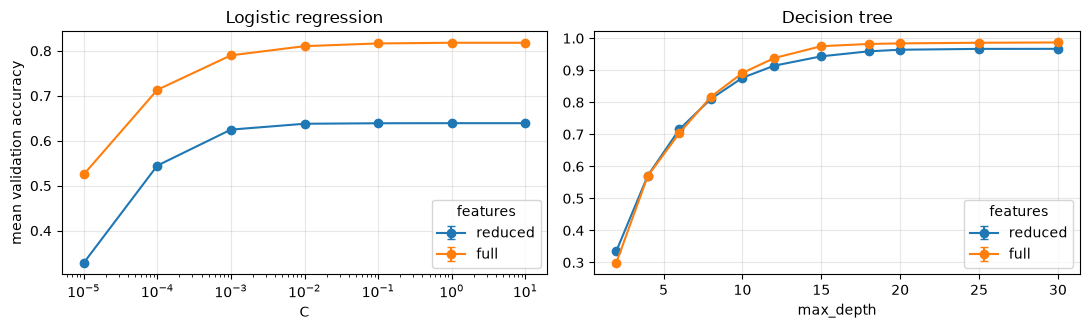

In [28]:
cv_tables = {stem: pd.read_csv(RESULTS_DIR / "metrics" / f"{stem}_cv.csv")
             for stem in ("logreg_reduced", "logreg_full", "decision_tree_reduced", "decision_tree_full")}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for fs in ("reduced", "full"):
    t = cv_tables[f"logreg_{fs}"]
    axes[0].errorbar(t["C"], t["val_mean"], yerr=t["val_std"], marker="o", capsize=3, label=fs)
    t = cv_tables[f"decision_tree_{fs}"]
    axes[1].errorbar(t["max_depth"], t["val_mean"], yerr=t["val_std"], marker="o", capsize=3, label=fs)
axes[0].set(xscale="log", xlabel="C", ylabel="mean validation accuracy", title="Logistic regression")
axes[1].set(xlabel="max_depth", title="Decision tree")
for ax in axes: ax.legend(title="features"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Re-applying each model's **own selection rule** to the saved CV tables gives back exactly the hyperparameter used in the final saved result:

In [29]:
rows = []
for fs in ("reduced", "full"):
    t = cv_tables[f"logreg_{fs}"]
    best = t.iloc[int(np.argmax(t["val_mean"]))]               # logreg.tune_C rule: highest mean val accuracy
    rows.append({"Config": f"logreg_{fs}", "Rule": "max", "Selected": f"C = {best['C']:g}",
                 "Val. accuracy": best["val_mean"], "Val. std": best["val_std"],
                 "Used in saved result": f"C = {load_result(f'logreg_{fs}')['params']['C']:g}"})
for fs in ("reduced", "full"):
    t = cv_tables[f"decision_tree_{fs}"]
    sel = decision_tree.select_depth(t.to_dict("records"), "one_sd")   # the project's function
    rows.append({"Config": f"decision_tree_{fs}", "Rule": "one_sd", "Selected": f"max_depth = {sel['max_depth']}",
                 "Val. accuracy": sel["val_mean"], "Val. std": sel["val_std"],
                 "Used in saved result": f"max_depth = {load_result(f'decision_tree_{fs}')['params']['max_depth']}"})
pd.DataFrame(rows).style.format({"Val. accuracy": "{:.2%}", "Val. std": "{:.2%}"}).hide(axis="index")

Config,Rule,Selected,Val. accuracy,Val. std,Used in saved result
logreg_reduced,max,C = 1,63.91%,0.12%,C = 1
logreg_full,max,C = 1,81.80%,0.08%,C = 1
decision_tree_reduced,one_sd,max_depth = 25,96.67%,0.08%,max_depth = 25
decision_tree_full,one_sd,max_depth = 30,98.67%,0.03%,max_depth = 30


* **Logistic regression:** validation accuracy plateaus from `C = 1` (C = 1 and C = 10 tie exactly), so weaker regularisation than the paper's 0.01 was chosen. The gain over C = 0.01 is small (+0.1 / +0.8 points).
* **Decision tree:** validation accuracy keeps rising up to depth 30, and the CV spread is very small (σ ≈ 0.03–0.08 %). Even the one-SD rule therefore picks deep trees: 25 (reduced) and 30 (full).
* **Random forest:** CV over depth {10…30} with 100 trees. The CV table was not saved as CSV, but the choice (depth 30, *max* rule) is recorded in the result JSON (section 10).
* **SVM / AdaBoost / MLP:** no CV was run. SVM used the paper's `C`; AdaBoost and MLP are fixed QUICK presets. This is recorded in each JSON's `cv` field.

## 14. Evaluation Metrics

All metrics come from `har.metrics.evaluate` / `confusion_df` and are computed on the **held-out test split**:

* **Accuracy**: fraction of test rows classified correctly. Easy to read, but dominated by the large classes.
* **Macro F1**: the F1 score (harmonic mean of precision and recall) computed **per class** and then **averaged with equal weight**. A model that ignores a small class such as *rope jumping* (2.5 % of rows) is penalised. Computed over all 12 labels.
* **Weighted F1**: per-class F1 averaged with weights proportional to each class's number of test rows. It sits close to accuracy.
* **Confusion matrix**: a 12 × 12 table of counts, with rows = true activity and columns = predicted activity. The diagonal holds the correct predictions; off-diagonal cells show *which* activities get confused.

**Toy illustration** (made-up labels, only to show how the functions behave, not a project result):

In [30]:
source(evaluate)
y_true_toy = np.array([1, 1, 1, 1, 2, 2, 2, 2, 24, 24])     # 3 classes, made-up
y_pred_toy = np.array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2])       # every "rope jumping" (24) row missed
print("TOY:", {k: round(v, 3) for k, v in evaluate(y_true_toy, y_pred_toy).items()})
print("-> accuracy 0.8 looks fine, but macro F1 is low: one class is never recognised.")

def evaluate(y_true, y_pred) -> dict:
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", labels=LABEL_ORDER,
                                       zero_division=0)),
            "weighted_f1": float(f1_score(y_true, y_pred, average="weighted",
                                          zero_division=0))}

TOY: {'accuracy': 0.8, 'macro_f1': 0.15, 'weighted_f1': 0.72}
-> accuracy 0.8 looks fine, but macro F1 is low: one class is never recognised.


**Check against real saved files.** The metrics stored in `decision_tree_full.json` can be recomputed **from the saved confusion matrix alone** (`results/confusion/decision_tree_full.csv`). This shows that the matrix and the reported numbers belong together:

In [31]:
cm_raw = pd.read_csv(RESULTS_DIR / "confusion" / "decision_tree_full.csv", index_col=0)
C_ = cm_raw.to_numpy(dtype=float)
tp, support, predicted = np.diag(C_), C_.sum(axis=1), C_.sum(axis=0)
precision = np.divide(tp, predicted, out=np.zeros_like(tp), where=predicted > 0)
recall = tp / support
f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
recomputed = {"Accuracy": tp.sum() / C_.sum(), "Macro F1": f1.mean(), "Weighted F1": (f1 * support).sum() / support.sum()}
saved = load_result("decision_tree_full")
saved = {"Accuracy": saved["test_accuracy"], "Macro F1": saved["test_macro_f1"], "Weighted F1": saved["test_weighted_f1"]}
pd.DataFrame({"From confusion matrix": recomputed, "Saved in JSON": saved}) \
    .assign(Match=lambda d: np.isclose(d.iloc[:, 0], d.iloc[:, 1], atol=1e-12)) \
    .style.format({"From confusion matrix": "{:.6%}", "Saved in JSON": "{:.6%}"})

,From confusion matrix,Saved in JSON,Match
Accuracy,99.819578%,99.819578%,True
Macro F1,99.782827%,99.782827%,True
Weighted F1,99.819572%,99.819572%,True


## 15. Model Comparison

All **8 completed configurations**, loaded from their result files. Configurations that were **not run** (SVM full, random forest reduced, AdaBoost full, MLP full) are **left out** rather than shown with placeholder numbers.

> ⚠️ Only the five **FULL** rows are directly comparable with one another. The SUBSAMPLE and QUICK rows used less data or less compute, as their status says.

In [32]:
COMPLETED = ["logreg_reduced", "logreg_full", "svm_rbf_reduced", "decision_tree_reduced",
             "decision_tree_full", "random_forest_full", "adaboost_reduced_quick", "mlp_reduced_quick"]
comparison = results_table(COMPLETED)[["Model", "Feature Set", "Status", "Accuracy", "Macro F1",
                                       "Weighted F1", "Fit Time (s)"]]
show(comparison)

Model,Feature Set,Status,Accuracy,Macro F1,Weighted F1,Fit Time (s)
Logistic Regression,Reduced,FULL,64.32%,60.17%,63.54%,36.8
Logistic Regression,Full,FULL,82.02%,79.00%,81.78%,53.3
SVM (RBF),Reduced,SUBSAMPLE,88.84%,87.18%,88.79%,12.0
Decision Tree,Reduced,FULL,99.30%,99.22%,99.30%,38.7
Decision Tree,Full,FULL,99.82%,99.78%,99.82%,122.3
Random Forest,Full,FULL,99.98%,99.98%,99.98%,"1,383.8"
AdaBoost,Reduced,QUICK,86.73%,85.13%,86.83%,431.6
MLP,Reduced,QUICK,91.61%,90.12%,91.47%,156.9


In [33]:
# Cross-check: the project's own comparison script finds exactly the same set of completed results
table = cr.build_table(*cr.discover(RESULTS_DIR))
done = table[table["test_accuracy"].notna()]
print("completed (compare_results):", sorted(done["stem"]))
print("not run                    :", sorted(table.loc[table["status"] == "NOT RUN", "stem"]))
assert sorted(done["stem"]) == sorted(COMPLETED)

completed (compare_results): ['adaboost_reduced_quick', 'decision_tree_full', 'decision_tree_reduced', 'logreg_full', 'logreg_reduced', 'mlp_reduced_quick', 'random_forest_full', 'svm_rbf_reduced']
not run                    : ['adaboost_full', 'mlp_full', 'random_forest_reduced', 'svm_rbf_full']


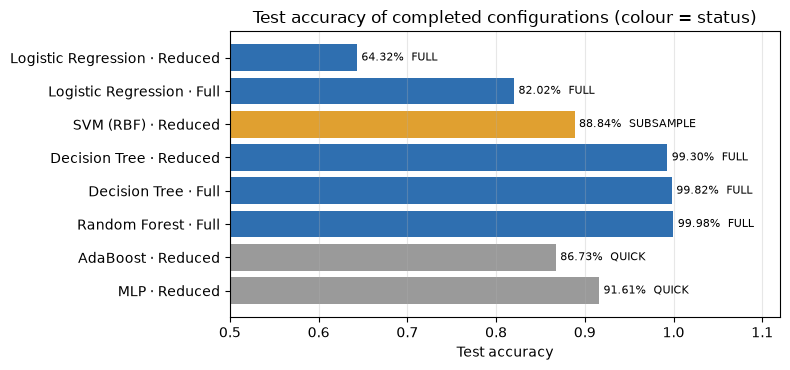

In [34]:
order = comparison.assign(label=comparison["Model"] + " · " + comparison["Feature Set"]).iloc[::-1]
colors = order["Status"].map({"FULL": "#2f6fb0", "SUBSAMPLE": "#e0a030", "QUICK": "#9a9a9a"})
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(order["label"], order["Accuracy"], color=colors)
for y, (acc, st) in enumerate(zip(order["Accuracy"], order["Status"])):
    ax.text(acc + 0.005, y, f"{acc:.2%}  {st}", va="center", fontsize=8)
ax.set(xlim=(0.5, 1.12), xlabel="Test accuracy", title="Test accuracy of completed configurations (colour = status)")
ax.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

**Take-aways from the FULL results**

* **Tree-based models dominate.** Random forest (99.98 %) > decision tree (99.82 % full / 99.30 % reduced) ≫ logistic regression (82.0 % / 64.3 %).
* **Full features beat reduced features** for every model with both results: +17.7 points for logistic regression, +0.5 points for the decision tree. Adding the chest and ankle sensors matters most for the linear model.
* **Cost:** one decision tree trains in ~2 min, while the forest takes ~23 min for a 0.16-point gain.

## 16. Confusion Matrix — Decision Tree, Full Features

Loaded from the **saved** `results/confusion/decision_tree_full.csv`, which was written by the experiment on the full test split, so nothing is recomputed. Rows are normalised to show the **recall per true activity**, and the counts are printed in each cell.

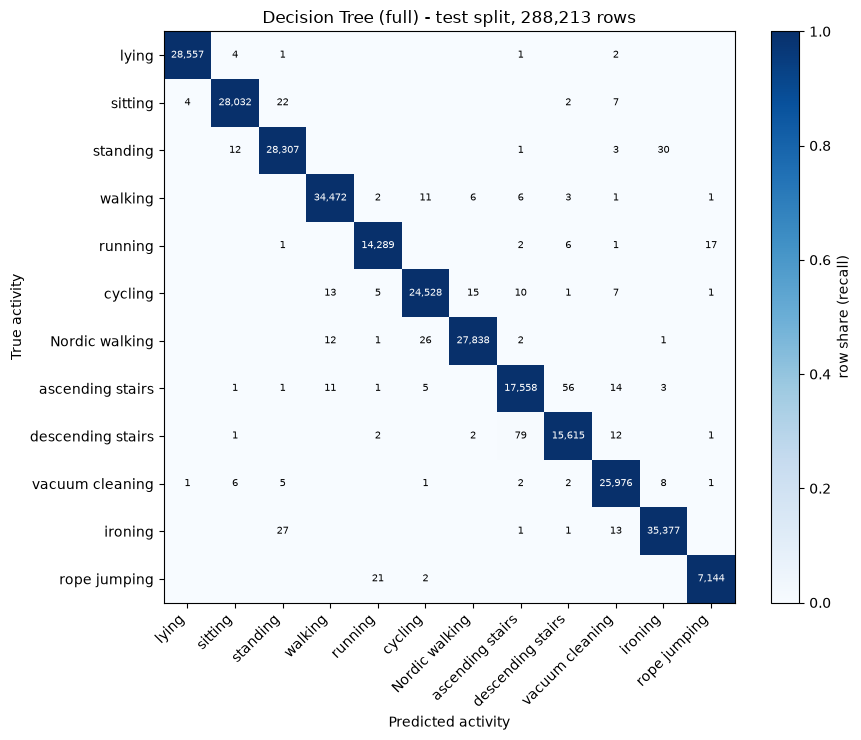

In [35]:
names = [ACTIVITY_NAMES[c] for c in LABEL_ORDER]
assert list(cm_raw.index) == [f"true_{c}" for c in LABEL_ORDER] and list(cm_raw.columns) == [f"pred_{c}" for c in LABEL_ORDER]
cm = pd.DataFrame(cm_raw.to_numpy(), index=names, columns=names)
norm = cm.div(cm.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(12), names, rotation=45, ha="right"); ax.set_yticks(range(12), names)
for i in range(12):
    for j in range(12):
        if cm.iat[i, j]:
            ax.text(j, i, f"{cm.iat[i, j]:,}", ha="center", va="center", fontsize=7,
                    color="white" if norm.iat[i, j] > 0.5 else "black")
ax.set(xlabel="Predicted activity", ylabel="True activity",
       title=f"Decision Tree (full) - test split, {int(cm.to_numpy().sum()):,} rows")
fig.colorbar(im, ax=ax, label="row share (recall)", fraction=0.046)
plt.tight_layout(); plt.show()

In [36]:
off = cm.to_numpy().copy(); np.fill_diagonal(off, 0)
top = [(names[i], names[j], off[i, j], off[i, j] / cm.iloc[i].sum())
       for i, j in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1][:5], off.shape))]
print("Lowest recall:", norm.to_numpy().diagonal().min().round(4), "-", names[int(norm.to_numpy().diagonal().argmin())])
pd.DataFrame(top, columns=["True", "Predicted as", "Rows", "Share of true class"]) \
    .style.format({"Share of true class": "{:.2%}", "Rows": "{:,}"}).hide(axis="index")

Lowest recall: 0.9938 - descending stairs


True,Predicted as,Rows,Share of true class
descending stairs,ascending stairs,79,0.50%
ascending stairs,descending stairs,56,0.32%
standing,ironing,30,0.11%
ironing,standing,27,0.08%
Nordic walking,cycling,26,0.09%


Every activity has recall above 99 % (lowest: *descending stairs*, 99.4 %). The largest remaining errors are between physically similar activities: **ascending ↔ descending stairs**, **standing ↔ ironing** (both upright, with little leg movement) and **Nordic walking → cycling**. These are the pairs where a single 10 ms sensor reading carries the least information.

## 17. Prediction Demo — Saved Decision Tree (Full)

`artifacts/decision_tree_full.joblib` is the **deployment artifact** used by the Streamlit dashboard. It was produced by `app/export_demo_model.py`, which:

1. refitted the reported FULL configuration (gini, `max_depth=30`, `min_samples_leaf=1`, `random_state=229`) on the frozen training split;
2. saved the model **only after** confirming that its test predictions reproduce the saved accuracy and confusion matrix exactly.

Here the artifact is only **loaded**, never trained. We use it to classify one **real row from the frozen held-out test split**. This is **offline inference on a stored test sample**, not real-time prediction.

In [37]:
ARTIFACT = REPO_ROOT / "artifacts" / "decision_tree_full.joblib"
art_meta = json.loads((REPO_ROOT / "artifacts" / "decision_tree_full_metadata.json").read_text())
model = joblib.load(ARTIFACT)
print(model)
print({k: art_meta[k] for k in ("feature_set", "feature_count", "seed", "split_fingerprint", "params")})
print("verified at export:", art_meta["verified"])

DecisionTreeClassifier(max_depth=30, random_state=229)
{'feature_set': 'full', 'feature_count': 31, 'seed': 229, 'split_fingerprint': '204cf31f6f415437', 'params': {'max_depth': 30, 'criterion': 'gini', 'min_samples_leaf': 1}}
verified at export: {'test_accuracy': 0.9981957788163615, 'accuracy_matches': True, 'confusion_matrix_matches': True, 'n_test': 288213}


In [38]:
if HAVE_PROCESSED:
    split = load_split()
    cols = ["row_id", "subject_id", "activity_id"] + FEATURE_SETS["full"]
    test = pq.read_table(PARQUET, columns=cols).take(split["test"]).to_pandas()   # held-out TEST rows only

    i = int(np.random.default_rng(SEED).integers(len(test)))      # one seeded, reproducible pick
    sample = test.iloc[i]
    x = sample[FEATURE_SETS["full"]].to_numpy(dtype=np.float32).reshape(1, -1)
    pred = int(model.predict(x)[0])
    actual = int(sample["activity_id"])

    print(f"Sample ID (row_id)  : {int(sample['row_id']):,}")
    print(f"Subject             : {int(sample['subject_id'])}")
    print(f"Actual activity     : {ACTIVITY_NAMES[actual]}")
    print(f"Predicted activity  : {ACTIVITY_NAMES[pred]}")
    print(f"Result              : {'CORRECT' if pred == actual else 'INCORRECT'}")
else:
    print("Processed data not found.")

Sample ID (row_id)  : 1,031,142
Subject             : 105
Actual activity     : vacuum cleaning
Predicted activity  : vacuum cleaning
Result              : CORRECT


The same artifact, applied to the **whole** test split (prediction takes well under a second), reproduces the saved result:

In [39]:
if HAVE_PROCESSED:
    X_test, y_test = test[FEATURE_SETS["full"]].to_numpy(np.float32), test["activity_id"].to_numpy()
    acc = evaluate(y_test, model.predict(X_test))["accuracy"]
    print(f"artifact accuracy on {len(y_test):,} test rows: {acc:.10f}")
    print(f"saved result (decision_tree_full.json)      : {load_result('decision_tree_full')['test_accuracy']:.10f}")

artifact accuracy on 288,213 test rows: 0.9981957788
saved result (decision_tree_full.json)      : 0.9981957788


## 18. Limitations

* **Random row-level split.** Following the report, rows from all subjects are pooled and split at random. The same people, and the same recording sessions, appear in both training and test data.
* **Temporal adjacency inflates results.** Sensor readings are taken every 10 ms. Neighbouring readings are almost identical and carry the same label, so for most test rows the training set contains a row from a few milliseconds earlier or later. Deep trees and forests exploit this, which is a large part of why they score ~99.8–99.98 % here versus 92.7–98.0 % in the report. A **subject-wise split** (`har.splits.make_subject_split`, leave whole people out) would measure generalisation to new users far more honestly and would give lower numbers.
* **Single readings, no windows.** Each sample is one instant. Typical HAR systems use features over time windows (means, variances, frequencies), which this protocol deliberately does not.
* **QUICK and SUBSAMPLE configurations.** The SVM used 20,000 train / 20,000 test rows (SUBSAMPLE). AdaBoost (20 trees, depth 6) and the MLP (5 epochs) are fixed QUICK presets with no tuning. None of these three is directly comparable to the FULL results.
* **Missing configurations.** SVM full, random forest reduced, AdaBoost full and MLP full were **not run** because of computational limits (laptop CPU and memory). They are absent, not estimated.
* **Tuning on a subsample.** CV used 200,000 of the 1.6 M training rows, to keep tuning affordable.
* **One deployment artifact.** Only **Decision Tree (full)** has a saved, verified model (`artifacts/`). All other models exist only as saved metrics.

## 19. Conclusion

The project implements an end-to-end, reproducible HAR pipeline on PAMAP2:

1. **Data:** raw protocol recordings → per-subject cleaning (heart-rate interpolation, transient label 0 removed, NaN rows dropped) → **1,921,420 rows, 12 activities**, stored as Parquet.
2. **Features:** a reduced set (hand IMU + heart rate, **11** features) and a full set (3 IMUs + heart rate, **31** features). Identifiers are blocked from being used as inputs.
3. **Protocol:** one **frozen** random 85/15 split (`seed 229`, fingerprint `204cf31f6f415437`; **1,633,207** train / **288,213** test rows). Hyperparameters are tuned by **5-fold CV on training rows only**.
4. **Models:** logistic regression, RBF-SVM, decision tree, random forest, AdaBoost and an MLP. All run through one shared runner and one result format.
5. **Results:** with FULL data, **tree ensembles perform best** (random forest 99.98 %, decision tree 99.82 % on full features), logistic regression is clearly limited (82.0 % / 64.3 %), and full features beat reduced features. SVM (SUBSAMPLE), AdaBoost and MLP (QUICK) are reported with their status and kept separate from the FULL comparison.
6. **Deployment:** the FULL decision tree is saved as a verified artifact. It reproduces the reported test accuracy exactly and powers the Streamlit prediction demo.

The very high accuracies should be read in light of the random row-level split (section 18). A subject-wise evaluation is the natural next step.